# Performance notes

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

import pylandstats as pls

This notebook serves to compare the performance of PyLandStats with that of [the R package landscapemetrics](https://github.com/r-spatialecology/landscapemetrics) [2], and to discuss the implementation details that determine it.

As a benchmark, both libraries compute the same set of metrics, namely the patch-level metrics, their mean, standard deviation and coefficient of variation at the class and landscape levels, and the class and landscape-level metrics that both libraries implement. Note that PyLandStats also implements the area-weighted mean, the median and the range of each patch metric, as well as the core area metrics, none of which landscapemetrics implements - these are therefore excluded from the benchmark (see the note at the end of this notebook on their cost).

The execution times below have been measured in the same computer, with the following processor:

```bash
$ cat /proc/cpuinfo  | grep 'name'| uniq
model name : Intel(R) Core(TM) i7-10510U CPU @ 1.80GHz
```

Note that the execution times vary noticeably between runs in this machine (a laptop), so the comparison below should be read as indicative of the order of magnitude rather than as a precise ratio.

The landscapemetrics execution times are measured with the [`metrics-benchmark.R`](https://github.com/martibosch/pylandstats/blob/main/docs/user-guide/metrics-benchmark.R) script of this repository (landscapemetrics 2.2.1, terra 1.9.34, R 4.5.3), which can be run with `pixi run -e benchmark benchmark-landscapemetrics <raster>`.

**Historical note**: an earlier version of this benchmark also compared against FRAGSTATS (v4.2) [1], whose execution times were obtained by manually selecting the metrics in its graphical user interface (run in Ubuntu by means of the [WineHQ](https://wiki.winehq.org/Ubuntu) compatibility layer for Windows applications). Since that cannot be scripted, it is no longer re-measured here. For the record, in an `Intel(R) Xeon(R) CPU E5-1620 0 @ 3.60GHz`, the first and second benchmarks below took 610 ms and 33.31 s with FRAGSTATS, against 14.27 s and 553.45 s with landscapemetrics v1.0 and 969 ms and 32.9 s with the PyLandStats of the time. Both libraries have become substantially faster since.

## Benchmarks

Let us first define the set of metrics to compute, which mirrors the one of the R script, and a function to make a very simple benchmark plot:

In [2]:
suffixes = ["mn", "sd", "cv"]
patch_metrics = [
    "area",
    "perimeter",
    "perimeter_area_ratio",
    "shape_index",
    "fractal_dimension",
    "euclidean_nearest_neighbor",
]
aggregation_metrics = [
    f"{metric}_{suffix}" for suffix in suffixes for metric in patch_metrics
]
class_metrics = [
    "total_area",
    "proportion_of_landscape",
    "number_of_patches",
    "patch_density",
    "largest_patch_index",
    "total_edge",
    "edge_density",
    "landscape_shape_index",
] + aggregation_metrics
landscape_metrics = [
    "total_area",
    "number_of_patches",
    "patch_density",
    "largest_patch_index",
    "total_edge",
    "edge_density",
    "landscape_shape_index",
    "contagion",
    "shannon_diversity_index",
] + aggregation_metrics


def benchmark_plot(execution_times):
    """Plot the execution time of each library as a bar plot."""
    x = np.arange(2)
    plt.bar(x, execution_times)
    plt.xticks(x, ["landscapemetrics", "PyLandStats"])
    plt.ylabel("execution time [s]")

### Benchmark 1: Canton of Vaud

We will first measure the execution times for the extract of the Canton of Vaud (Switerland) derived from the [CORINE Land Cover dataset](https://land.copernicus.eu/pan-european/corine-land-cover) of the year 2000, reclassified into urban and non-urban classes.

In [3]:
ls = pls.Landscape("../data/raw/clc/vaud_g100_clc00_V18_5.tif", res=(100, 100))

print(
    f"Landscape size [pixels]: {ls.landscape_arr.shape[0]}x{ls.landscape_arr.shape[1]}"
)
print(f"Number of classes: {len(ls.classes)}")

Landscape size [pixels]: 889x916
Number of classes: 2


In [4]:
start = time.perf_counter()
patch_df = ls.compute_patch_metrics_df(metrics=patch_metrics)
class_df = ls.compute_class_metrics_df(metrics=class_metrics)
landscape_df = ls.compute_landscape_metrics_df(metrics=landscape_metrics)
execution_time = time.perf_counter() - start
execution_time

0.23529313399922103

The execution time of the above cell (in seconds) is to be compared against the 1.77 s of landscapemetrics, which gives us the following plot:

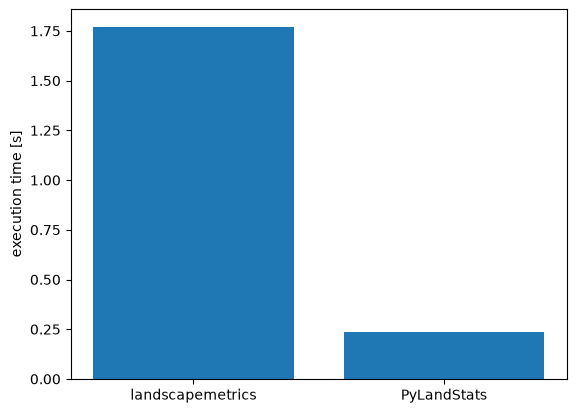

In [5]:
benchmark_plot([1.77, execution_time])

### Benchmark 2: Cantons of Bern and Valais

We will now measure the execution times for an extract of the cantons of Bern and Valais (Switzerland), also derived from the CORINE Land Cover dataset of the year 2000, however, this time without reclassifying the land cover classes.

In [6]:
ls = pls.Landscape("../data/raw/clc/bern_valais_g100_clc00.tif", res=(100, 100))

print(
    f"Landscape size [pixels]: {ls.landscape_arr.shape[0]}x{ls.landscape_arr.shape[1]}"
)
print(f"Number of classes: {len(ls.classes)}")

Landscape size [pixels]: 1640x1319
Number of classes: 28


In [7]:
start = time.perf_counter()
patch_df = ls.compute_patch_metrics_df(metrics=patch_metrics)
class_df = ls.compute_class_metrics_df(metrics=class_metrics)
landscape_df = ls.compute_landscape_metrics_df(metrics=landscape_metrics)
execution_time = time.perf_counter() - start
execution_time

/home/martibosch/data-science/pylandstats-notebooks/src/pylandstats/src/pylandstats/landscape.py:1309: RuntimeWarning: Class 10 has less than 2 patches. Euclidean-nearest-neighbor might contain nan values
  warnings.warn(


/home/martibosch/data-science/pylandstats-notebooks/src/pylandstats/src/pylandstats/landscape.py:1324: RuntimeWarning: Class 10 has less than 2 patches. Euclidean-nearest-neighbor might contain nan values
  warnings.warn(


/home/martibosch/data-science/pylandstats-notebooks/src/pylandstats/src/pylandstats/landscape.py:1324: RuntimeWarning: Class 10 has less than 2 patches. Euclidean-nearest-neighbor might contain nan values
  warnings.warn(
/home/martibosch/data-science/pylandstats-notebooks/src/pylandstats/src/pylandstats/landscape.py:1309: RuntimeWarning: Class 10 has less than 2 patches. Euclidean-nearest-neighbor might contain nan values
  warnings.warn(
/home/martibosch/data-science/pylandstats-notebooks/src/pylandstats/src/pylandstats/landscape.py:1309: RuntimeWarning: Class 10 has less than 2 patches. Euclidean-nearest-neighbor might contain nan values
  warnings.warn(


3.5803555909660645

The execution time of the above cell (in seconds) is to be compared against the 38.98 s of landscapemetrics, which gives us the following plot:

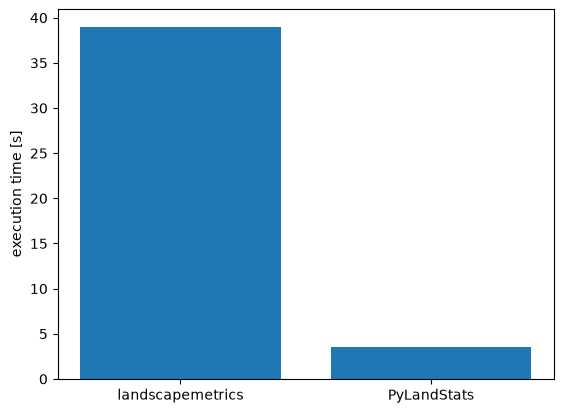

In [8]:
benchmark_plot([38.98, execution_time])

## PyLandStats performance and implementation details

In PyLandStats, each landscape is a Python object, upon which Python properties are employed to cache results that are computationally expensive to obtain and can later be accessed in constant (almost immediate) time. This mechanism is exploited to cache intermediate results that are later used to compute the metrics. More precisely, instances of the Landscape class cache the list of patches, each with its respective LULC class, area, perimeter and nearest-neigbhor distance, as well as the pixel adjacency matrix, i.e., the number of adjacencies between pixels of each landscape class (including adjacencies between pixels of the same class).

To illustrate such mechanism, let us re-instantiate the landscape for the Cantons of Bern and Valais:

In [9]:
ls = pls.Landscape("../data/raw/clc/bern_valais_g100_clc00.tif", res=(100, 100))

Right after the instantiation of a landscape object, none of the attributes listed below are defined:

In [10]:
print(hasattr(ls, "_cached_num_patches_dict"))
print(hasattr(ls, "_cached_patch_area_ser"))
print(hasattr(ls, "_cached_patch_perimeter_ser"))

False
False
False


Nevertheless, after computing an area-related, e.g., `area`:

In [11]:
%%time
area = ls.area()

CPU times: user 634 ms, sys: 146 μs, total: 635 ms
Wall time: 634 ms


the Python properties defined in the `Landscape` class will set the `_cached_num_patches_dict` (number of patches of each LULC class) and `_cached_patch_area_ser` (area of each patch) attributes, which can hereafter be accessed in constant (almost immediate) time:

In [12]:
ls._cached_num_patches_dict

{np.uint8(1): 7,
 np.uint8(2): 427,
 np.uint8(3): 52,
 np.uint8(4): 2,
 np.uint8(6): 11,
 np.uint8(7): 8,
 np.uint8(9): 2,
 np.uint8(10): 1,
 np.uint8(11): 14,
 np.uint8(12): 191,
 np.uint8(15): 31,
 np.uint8(16): 11,
 np.uint8(18): 473,
 np.uint8(20): 84,
 np.uint8(21): 39,
 np.uint8(23): 89,
 np.uint8(24): 533,
 np.uint8(25): 579,
 np.uint8(26): 329,
 np.uint8(27): 209,
 np.uint8(29): 72,
 np.uint8(30): 19,
 np.uint8(31): 218,
 np.uint8(32): 490,
 np.uint8(34): 151,
 np.uint8(35): 6,
 np.uint8(40): 8,
 np.uint8(41): 31}

In [13]:
ls._cached_patch_area_ser.head()

0     590000
1     950000
2     710000
3    1110000
4     500000
Name: area, dtype: int64

Similarly, after computing a perimeter-related metric, e.g., `perimeter_area_ratio`, the attribute `_cached_patch_perimeter_ser` (perimeter of each patch) will be set, and hereafter accessible in constant time:

In [14]:
%%time
perimeter = ls.perimeter()

CPU times: user 607 ms, sys: 1.03 ms, total: 608 ms
Wall time: 608 ms


In [15]:
ls._cached_patch_perimeter_ser.head()

0    5200
1    5200
2    6000
3    8600
4    4800
Name: perimeter, dtype: int64

Note that after the area and perimeter of each patch are cached, the computation of other area, edge and shape metrics is orders of magnitude faster

In [16]:
%%time
frac = ls.fractal_dimension()

CPU times: user 827 μs, sys: 0 ns, total: 827 μs
Wall time: 789 μs


And the same applies to the computations that require the class adjacency matrix

In [17]:
hasattr(ls, "_cached_adjacency_df")

False

In [18]:
%%time
ed = ls.edge_density()

CPU times: user 39.2 ms, sys: 17 μs, total: 39.2 ms
Wall time: 39 ms


In [19]:
ls._cached_adjacency_df.head()

1.0      2.0     3.0    4.0     6.0    7.0    9.0    \
direction  class_val                                                        
horizontal 1.0        818.0    140.0    13.0   10.0     0.0    0.0    0.0   
           2.0        140.0  72852.0   520.0   28.0    23.0    2.0    0.0   
           3.0         13.0    520.0  4598.0    5.0     4.0    0.0    3.0   
           4.0         10.0     28.0     5.0   98.0     0.0    0.0    0.0   
           6.0          0.0     23.0     4.0    0.0  1322.0    0.0    0.0   

                      10.0   11.0    12.0   ...  27.0   29.0   30.0   31.0   \
direction  class_val                        ...                               
horizontal 1.0          0.0    0.0     0.0  ...    0.0    0.0    0.0    0.0   
           2.0         22.0  102.0  6583.0  ...   30.0    4.0    1.0    4.0   
           3.0          2.0   36.0   356.0  ...    2.0    0.0    0.0    0.0   
           4.0          0.0    0.0     0.0  ...    0.0    0.0    0.0    0.0   
           6.0          0.0    0.0    77.0  ...    0.0    0.0    0.0    0.0   

                      32.0   34.0   35.0   40.0   41.0   255.0  
direction  class_val                                            
horizontal 1.0          0.0    0.0    0.0    0.0    0.0    0.0  
           2.0         21.0    0.0   13.0   72.0  295.0  119.0  
           3.0          0.0    0.0    0.0    1.0    7.0    8.0  
           4.0          0.0    0.0    0.0    0.0    0.0    0.0  
           6.0          0.0    0.0    0.0    0.0    0.0    0.0  

[5 rows x 29 columns]

In [20]:
%%time
lsi = ls.landscape_shape_index()

CPU times: user 3.6 ms, sys: 32 μs, total: 3.63 ms
Wall time: 3.44 ms


But it is when it comes to the computation of the inter-patch nearest-neighbor distances (the most computationally expensive task) that performance gains become more significant:

In [21]:
hasattr(ls, "_cached_patch_euclidean_nearest_neighbor_ser")

False

In [22]:
%%time
enn = ls.euclidean_nearest_neighbor()

CPU times: user 5.24 s, sys: 130 ms, total: 5.37 s
Wall time: 2.03 s


/home/martibosch/data-science/pylandstats-notebooks/src/pylandstats/src/pylandstats/landscape.py:1309: RuntimeWarning: Class 10 has less than 2 patches. Euclidean-nearest-neighbor might contain nan values
  warnings.warn(


In [23]:
ls._cached_patch_euclidean_nearest_neighbor_ser.head()

0    23584.952830
1      360.555128
2      316.227766
3      316.227766
4    18112.150618
Name: euclidean_nearest_neighbor, dtype: float64

In [24]:
%%time
enn_l_sd = ls.euclidean_nearest_neighbor_sd()

CPU times: user 1.72 ms, sys: 0 ns, total: 1.72 ms
Wall time: 1.61 ms


The euclidean nearest-neighbor used to be by far the main performance bottleneck of PyLandStats, i.e., 26.6 s out of the 32.9 s that the second benchmark took in the original version of this notebook. It is now computed by querying a single k-d tree built with the pixels of all the patches of a class (instead of building one k-d tree per patch), which is why the cell above only takes a few seconds.

The bottleneck is now the core area metrics, which landscapemetrics does not implement and which are therefore excluded from the benchmarks above: computing *every* metric of the second benchmark, i.e., also the core area ones and the area-weighted mean, median and range of each patch metric, takes about 1 min 15 s in the same machine, against the 5.19 s of the benchmark above.

It is therefore recommended that analysis cases which do not require the core area (or the euclidean nearest-neighbor) metrics avoid computing them by making use of the `metrics` keyword argument of the `compute_patch_metrics_df`, `compute_class_metrics_df` and `compute_landscape_metrics_df` methods.

## References

1. Kevin McGarigal, Sam A Cushman, and Eduard Ene. Fragstats v4: spatial pattern analysis program for categorical and continuous maps. Computer software program produced by the authors at the University of Massachusetts, Amherst. Available at: http://www.umass.edu/landeco/research/fragstats/fragstats.html, 2012.
2. Maximilian HK Hesselbarth, Marco Sciaini, Kimberly A With, Kerstin Wiegand, and Jakub Nowosad. landscapemetrics: an open-source r tool to calculate landscape metrics. Ecography, 2019.